# Coleta de Dados

Coleta e preparo da base de dados.

- **Etapa 1:** preços e volatilidade realizada (Yahoo Finance)
- **Etapa 2:** SVI semanal por ticker (Google Trends)
- **Etapa 3:** teste de estacionariedade ADF
- **Etapa 4:** construção da base final (merge preços + SVI)

Os arquivos gerados são salvos em `./data/` e carregados pelo notebook `02_modelos.ipynb`.

In [2]:
import time
import math
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
# import yfinance as yf

# from pytrends.request import TrendReq
from datetime import datetime, timedelta
from statsmodels.tsa.stattools import adfuller


In [21]:
# ──────────────────────────────────────────────────────────────
# CONFIGURAÇÕES
# ──────────────────────────────────────────────────────────────
VOLUME_MIN_DIARIO = 1_000

SEMANAS_UTEIS  = 260                              # semanas utilizáveis após svi_log_dev
SEMANAS_PERDA  = 8                                # perdidas no cálculo svi_log_dev
SEMANAS  = SEMANAS_UTEIS + SEMANAS_PERDA          # 268 semanas a coletar
# Última semana: 15/03/26 (dom) → 21/03/26 (sáb)
# Yahoo usa fechamento de sexta → DATA_FIM = 21/03 garante que 20/03 (sex) é capturado
DATA_FIM    = datetime(2026, 3, 21).strftime("%Y-%m-%d")
# Início da semana 1: recua (SEMANAS - 1) semanas a partir do início da última semana
DATA_INICIO = (datetime(2026, 3, 15) - timedelta(weeks=SEMANAS - 1)).strftime("%Y-%m-%d")

PAUSA_TRENDS = 30     # segundos entre requisições
CAMINHO  = "./data/"

## Dados financeiros

In [16]:
# ──────────────────────────────────────────────────────────────
# ETAPA 1 — PREÇOS
# ──────────────────────────────────────────────────────────────

# Todos os ticker
tickers = pd.read_csv("./data/acoes-listadas-b3.csv")
TERMOS = list(tickers.Ticker)
tickers_yf = [t + ".SA" for t in TERMOS]

dados_raw = yf.download(
    tickers_yf, start=DATA_INICIO, end=DATA_FIM,
    auto_adjust=True, progress=True,
)

registros_acoes = []
for ticker_yf in tickers_yf:

    try:
        close  = dados_raw["Close"][ticker_yf].dropna()
        volume = dados_raw["Volume"][ticker_yf].dropna()

        if len(close) < SEMANAS * 5 * 0.85:
            print(f"  [SKIP] {ticker_yf} — histórico insuficiente ({len(close)} dias)")
            continue

        vol_fin = (volume * close.mean()).mean()
        if vol_fin < VOLUME_MIN_DIARIO:
            print(f"  [SKIP] {ticker_yf} — liquidez insuficiente")
            continue

        registros_acoes.append({
            "ticker_yf": ticker_yf,
            "dias": len(close),
            "vol_fin_medio": round(vol_fin, 2),
        })

    except Exception as e:
        print(f"  [ERRO] {ticker_yf}: {e}")

df_acoes = pd.DataFrame(registros_acoes)
df_acoes.to_csv("./data/acoes_elegiveis.csv", index=False)
print(f"\n✅ {len(df_acoes)} ações elegíveis → acoes_elegiveis.csv")

[***                    7%                       ]  28 of 387 completed$BIOM11.SA: possibly delisted; no timezone found
[*******               14%                       ]  54 of 387 completed$AZEV11.SA: possibly delisted; no timezone found
[***************       31%                       ]  120 of 387 completed$PINE11.SA: possibly delisted; no timezone found
[**********************70%*********              ]  271 of 387 completed$MERC4.SA: possibly delisted; no price data found  (1d 2021-01-31 -> 2026-03-21) (Yahoo error = "No data found, symbol may be delisted")
[*********************100%***********************]  387 of 387 completed

4 Failed downloads:
['BIOM11.SA', 'AZEV11.SA', 'PINE11.SA']: possibly delisted; no timezone found
['MERC4.SA']: possibly delisted; no price data found  (1d 2021-01-31 -> 2026-03-21) (Yahoo error = "No data found, symbol may be delisted")


  [SKIP] ONCO3.SA — histórico insuficiente (1122 dias)
  [SKIP] NATU3.SA — histórico insuficiente (185 dias)
  [SKIP] MOTV3.SA — histórico insuficiente (229 dias)
  [SKIP] AXIA7.SA — histórico insuficiente (59 dias)
  [SKIP] EMBJ3.SA — histórico insuficiente (98 dias)
  [SKIP] AUAU3.SA — histórico insuficiente (53 dias)
  [SKIP] AZTE3.SA — histórico insuficiente (273 dias)
  [SKIP] AURE3.SA — histórico insuficiente (995 dias)
  [SKIP] IGTI11.SA — histórico insuficiente (1081 dias)
  [SKIP] IGTI11.SA — histórico insuficiente (1081 dias)
  [SKIP] BRST3.SA — histórico insuficiente (320 dias)
  [SKIP] VITT3.SA — histórico insuficiente (1134 dias)
  [SKIP] VTRU3.SA — histórico insuficiente (445 dias)
  [SKIP] RENT4.SA — histórico insuficiente (55 dias)
  [SKIP] CYRE4.SA — histórico insuficiente (54 dias)
  [SKIP] TOKY3.SA — histórico insuficiente (212 dias)
  [SKIP] ATED3.SA — histórico insuficiente (316 dias)
  [SKIP] OBTC3.SA — histórico insuficiente (112 dias)
  [SKIP] AMOB3.SA — históri

In [17]:
# ──────────────────────────────────────────────────────────────
# ETAPA 2 — VOLATILIDADE REALIZADA
# ──────────────────────────────────────────────────────────────

series_semanais = []
for _, row in df_acoes.iterrows():
    try:
        close  = dados_raw["Close"][row["ticker_yf"]].dropna()
        volume = dados_raw["Volume"][row["ticker_yf"]].dropna()

        df_d = pd.DataFrame({"close": close, "volume": volume})
        df_d.index = pd.to_datetime(df_d.index)

        df_d["log_ret"] = np.log(df_d["close"] / df_d["close"].shift(1))

        # Agrega semanalmente (semana fecha na sexta)
        wk = df_d.resample("W-FRI").agg(
            preco_abertura   = ("close",   "first"),
            preco_fechamento = ("close",   "last"),
            volume_total     = ("volume",  "sum"),
            n_preços         = ("log_ret", "count"), # nº de pregões na semana
            rv               = ("log_ret", lambda x: (x**2).sum()),  # RV = Σ r²
            ret_semanal      = ("log_ret", "sum"),
        ).dropna(subset=["rv"])

        wk["ticker_yf"] = row["ticker_yf"]
        wk["ticker_b3"] = row["ticker_yf"].replace(".SA", "")
        series_semanais.append(wk.reset_index().rename(columns={"Date": "semana"}))

    except Exception as e:
        print(f"  [ERRO preços {row['ticker_yf']}]: {e}")

df_precos = pd.concat(series_semanais, ignore_index=True)
print(f"✅ {len(df_precos)} linhas → precos_semanais.csv")

✅ 92547 linhas → precos_semanais.csv


In [19]:
# Retirar ações que não possuem o número de semanas correto
ticker_counts = df_precos.groupby("ticker_b3")["semana"].count()
tickers_corretos = ticker_counts[ticker_counts == SEMANAS].index
df_precos = df_precos[df_precos["ticker_b3"].isin(tickers_corretos)]

df_precos.to_csv("./data/precos_semanais.csv", index=False)
print(f"✅ {len(df_precos)} linhas → precos_semanais.csv")

✅ 84152 linhas → precos_semanais.csv


## GOOGLE TRENDS: SVI POR TICKER

In [29]:
# ──────────────────────────────────────────────────────────────
# ETAPA 3 — GOOGLE TRENDS: SVI POR TICKER
# ──────────────────────────────────────────────────────────────

pytrends = TrendReq(hl="pt-BR", tz=-180)

def coletar_svi(ticker):
    """Retorna DataFrame semanal do SVI para um ticker ou None."""
    try:
        pytrends.build_payload(
            kw_list=[ticker],
            timeframe=f"{DATA_INICIO} {DATA_FIM}",
            geo="BR",
            gprop="",
        )
        df = pytrends.interest_over_time()
        if df.empty:
            return None
        df = df.drop(columns=["isPartial"], errors="ignore")
        df.columns = ["svi"]
        df.index.name = "semana"
        return df.reset_index()
    except Exception as e:
        if "429" in str(e):
            raise
        print(f"[ERRO '{ticker}']: {e}")
        return None


todos_trends = []
log_coleta   = []
tickers_validos = list(df_precos["ticker_b3"].unique())

for ticker in tickers_validos:

    print(f"> {ticker}...")

    while True:
        try:
            df_t = coletar_svi(ticker)
            break
        except Exception:
            print(f"\nPausa de {PAUSA_TRENDS}s (429 — requests demais)...")
            time.sleep(PAUSA_TRENDS)

    if df_t is None:
        print("VAZIO")
        log_coleta.append({
            "ticker": ticker, "status": "vazio",
            "semanas": 0, "svi_media": None, "svi_std": None,
        })
        continue

    svi_media = round(df_t["svi"].mean(), 2)
    svi_std   = round(df_t["svi"].std(), 2)
    svi_zeros = (df_t["svi"] == 0).mean()
    print(f"OK | {len(df_t)} sem | média={svi_media:.1f} "
            f"std={svi_std:.1f} zeros={svi_zeros:.0%}")

    for _, tr in df_t.iterrows():
        todos_trends.append({
            "semana": tr["semana"],
            "svi_zeros_pct": round(svi_zeros * 100, 4),
            "ticker_b3": ticker,
            "svi":    tr["svi"],
        })

    log_coleta.append({
        "ticker":       ticker,
        "status":       "ok",
        "semanas":      len(df_t),
        "svi_media":    svi_media,
        "svi_std":      svi_std,
        "svi_zeros_pct": round(svi_zeros * 100, 4),
    })


df_trends = pd.DataFrame(todos_trends)
df_log    = pd.DataFrame(log_coleta)

df_trends.to_csv("./data/google_trends_svi.csv", index=False)
df_log.to_csv("./data/log_coleta_svi.csv", index=False)

print(f"\n✅ {len(df_trends)} linhas → google_trends_svi.csv")
print(f"✅ Log de coleta    → log_coleta_svi.csv")

> PETR4...

Pausa de 30s (429 — requests demais)...

Pausa de 30s (429 — requests demais)...
OK | 268 sem | média=17.5 std=7.8 zeros=0%
> B3SA3...
OK | 268 sem | média=20.0 std=10.7 zeros=0%
> HAPV3...
OK | 268 sem | média=10.6 std=9.0 zeros=0%
> BEEF3...
OK | 268 sem | média=26.5 std=12.6 zeros=0%
> GMAT3...
OK | 268 sem | média=26.4 std=15.5 zeros=0%
> ENEV3...
OK | 268 sem | média=14.4 std=11.9 zeros=4%
> CSAN3...
OK | 268 sem | média=18.5 std=9.4 zeros=0%
> COGN3...
OK | 268 sem | média=27.1 std=14.5 zeros=0%
> MBRF3...
OK | 268 sem | média=4.3 std=14.5 zeros=90%
> BBDC4...
OK | 268 sem | média=24.4 std=9.3 zeros=0%
> VAMO3...
OK | 268 sem | média=29.1 std=19.6 zeros=0%
> ITUB4...

Pausa de 30s (429 — requests demais)...
OK | 268 sem | média=41.3 std=12.7 zeros=0%
> ABEV3...

Pausa de 30s (429 — requests demais)...
OK | 268 sem | média=12.3 std=7.4 zeros=0%
> CPLE3...
OK | 268 sem | média=40.0 std=19.9 zeros=1%
> BBAS3...
OK | 268 sem | média=20.7 std=13.3 zeros=0%
> ITSA4...
OK | 

## ESTACIONARIEDADE DO SVI (ADF POR TICKER)

In [31]:
# ──────────────────────────────────────────────────────────────
# ETAPA 4 — ESTACIONARIEDADE (ADF POR TICKER)
# ──────────────────────────────────────────────────────────────

NIVEL_SIGNIFICANCIA = 0.05

# A variável mede o desvio (deviation) logarítmico do SVI atual em relação à mediana das 8 semanas anteriores:
# Ou seja: o quanto o SVI desta semana está acima ou abaixo do seu nível "normal" recente.
def calc_svi_log_dev(svi):
    """log1p(svi_t) - log1p(mediana das 8 semanas anteriores)."""
    svi = np.asarray(svi, dtype=float)
    n = len(svi)
    out = np.full(n, np.nan)
    for i in range(8, n):
        med = np.nanmedian(svi[i - 8 : i])
        out[i] = np.log1p(svi[i]) - np.log1p(med)
    return out

def teste_adf(serie, nome=""):
    """
    Roda o ADF e retorna dict com estatística, p-valor e conclusão.
    Usa seleção automática de lags (método 'AIC').
    """
    serie = serie.dropna()
    if len(serie) < 10:
        return {"stat": None, "pvalor": None, "estacionaria": None, "obs": "série curta"}

    try:
        stat, pvalor, _, _, valores_criticos, _ = adfuller(serie, autolag="AIC")
        estacionaria = pvalor < NIVEL_SIGNIFICANCIA

        print(f"      {'[OK]' if estacionaria else '[RAIZ UNITÁRIA]'} {nome}: "
            f"stat={stat:.3f}  p={pvalor:.4f}  {'estacionária' if estacionaria else 'não estacionária'}")

        return {
            "stat":         round(stat, 4),
            "pvalor":       round(pvalor, 4),
            "cv_1pct":      round(valores_criticos["1%"], 3),
            "cv_5pct":      round(valores_criticos["5%"], 3),
            "cv_10pct":     round(valores_criticos["10%"], 3),
            "estacionaria": estacionaria,
            "obs":          "",
        }
    except:
        return {
            "stat":         np.nan,
            "pvalor":       np.nan,
            "cv_1pct":      np.nan,
            "cv_5pct":      np.nan, 
            "cv_10pct":     np.nan, 
            "estacionaria": False,
            "obs":          "Erro no teste adf",
        }

In [ ]:
resultados_adf = []

for ticker, grupo in df_trends.groupby("ticker_b3"):

    svi = grupo.sort_values("semana")["svi"].reset_index(drop=True)

    print(f"SVI: {ticker}")

    # ── ADF no nível ──────────────────────────────────────────
    adf_nivel = teste_adf(svi, "SVI nível")

    # ── Primeira diferença e ADF ──────────────────────────────
    svi_diff  = svi.diff()
    adf_diff  = teste_adf(svi_diff, "SVI Δ(1)")

    # ── log-dev SVI (M3) e ADF ────────────────────────────────
    svi_log_dev      = pd.Series(calc_svi_log_dev(svi.values))
    adf_log_dev      = teste_adf(svi_log_dev, "svi_log_dev")

    # ── exp-dev SVI: exp(svi_log_dev) = (1+svi_t)/(1+mediana_8sem) ─────────
    # Razão multiplicativa (sempre > 0, centrada em 1). Mesma informação do
    # log-dev, mas estritamente positiva — usada como regressor externo no
    # GARCH-X/eGARCH-X (garante contribuição positiva na variância condicional).
    svi_exp_dev      = np.exp(svi_log_dev)
    adf_exp_dev      = teste_adf(svi_exp_dev, "svi_exp_dev")

    resultados_adf.append({
        "ticker_b3":                   ticker,
        # nível
        "svi_adf_stat":             adf_nivel["stat"],
        "svi_adf_pvalor":           adf_nivel["pvalor"],
        "svi_estacionario":         adf_nivel["estacionaria"],
        # primeira diferença
        "svi_diff_adf_stat":        adf_diff["stat"],
        "svi_diff_adf_pvalor":      adf_diff["pvalor"],
        "svi_diff_estacionario":    adf_diff["estacionaria"],
        # log-dev
        "svi_log_dev_adf_stat":        adf_log_dev["stat"],
        "svi_log_dev_adf_pvalor":      adf_log_dev["pvalor"],
        "svi_log_dev_estacionario":    adf_log_dev["estacionaria"],
        # exp-dev (razão positiva)
        "svi_exp_dev_adf_stat":        adf_exp_dev["stat"],
        "svi_exp_dev_adf_pvalor":      adf_exp_dev["pvalor"],
        "svi_exp_dev_estacionario":    adf_exp_dev["estacionaria"],
    })

    mask = df_trends["ticker_b3"] == ticker
    df_trends.loc[mask, "svi_diff"]     = svi_diff.values
    df_trends.loc[mask, "svi_log_dev"]  = svi_log_dev.values
    df_trends.loc[mask, "svi_exp_dev"]  = svi_exp_dev.values

In [ ]:
# ── Bases finais ──────────────────────────────────────────────
df_adf = pd.DataFrame(resultados_adf)

df_adf.to_csv("./data/log_adf_svi.csv", index=False)
df_trends.to_csv("./data/google_trends_svi.csv", index=False)

# ── Resumo ────────────────────────────────────────────────────
n          = len(df_adf)
n_nivel_ok = df_adf["svi_estacionario"].sum()
n_diff_ok  = df_adf["svi_diff_estacionario"].sum()
n_log_ok   = df_adf["svi_log_dev_estacionario"].sum()
n_exp_ok   = df_adf["svi_exp_dev_estacionario"].sum()

print(f"\n{'─'*55}")
print(f"  SVI nível estacionário:           {n_nivel_ok}/{n} tickers")
print(f"  SVI Δ(1)  estacionário:           {n_diff_ok}/{n} tickers")
print(f"  svi_log_dev estacionário:         {n_log_ok}/{n} tickers")
print(f"  svi_exp_dev estacionário:         {n_exp_ok}/{n} tickers")
print(f"\n✅ google_trends_svi.csv  → svi + svi_diff + svi_log_dev + svi_exp_dev por semana")
print(f"✅ log_adf_svi.csv        → resultado ADF por ticker")

## Base de dados final

In [ ]:
# ──────────────────────────────────────────────────────────────
# ETAPA 5 — MERGE: PREÇOS + TRENDS
# Uma linha por (semana, ticker)
# ──────────────────────────────────────────────────────────────

df_trends["semana"] = pd.to_datetime(df_trends["semana"])
df_precos["semana"] = pd.to_datetime(df_precos["semana"])

# Alinha domingo (Trends) → sexta (preços)
df_trends_temp = df_trends.copy()
df_trends_temp["semana"] = df_trends_temp["semana"] + pd.offsets.Week(weekday=4)

df_final = pd.merge(
    df_precos,
    df_trends_temp[["semana","ticker_b3","svi_zeros_pct","svi","svi_diff","svi_log_dev","svi_exp_dev"]],
    on=["semana","ticker_b3"],
    how="inner",
).sort_values(["ticker_b3","semana"]).reset_index(drop=True)

# Selecionar apenas o ticker com svi_exp_dev estacionário (variável usada nos modelos)
df_final = df_final[df_final["ticker_b3"].isin(df_adf[df_adf['svi_exp_dev_estacionario'] == True]["ticker_b3"])]

# Retirar os valores NaN das 8 primeiras semanas do svi_exp_dev
df_final = df_final[df_final["svi_exp_dev"].notna()]

# Retirar ativos com número de semanas errada
ticker_counts = df_final.groupby("ticker_b3")["semana"].count()
tickers_ok = ticker_counts[ticker_counts == (SEMANAS - 8)].index
df_final = df_final[df_final["ticker_b3"].isin(tickers_ok)]

df_final.to_csv("./data/base_final_tcc.csv", index=False)

print(f"✅ BASE FINAL → base_final_tcc.csv")

In [ ]:
# Todos os ticker precisam conter 260 semanas
ticker_counts = df_final.groupby("ticker_b3")["semana"].count()
tickers_errados = ticker_counts[ticker_counts != 260].index
tickers_errados

Index([], dtype='str', name='ticker_b3')

<Axes: >

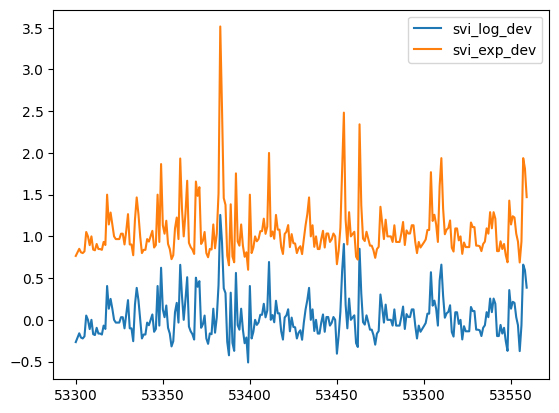

In [12]:
df_final = pd.read_csv("./data/base_final_tcc.csv")
df_final[df_final["ticker_b3"] == "PETR4"][['svi_log_dev', 'svi_exp_dev']].plot()